In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

In [7]:
df = pd.read_csv('D:/1kpsD9/Project/MAJOR/fruits/fruit_data_with_colors.txt',sep='\t')

In [8]:
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [10]:
df.shape

(59, 7)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fruit_label    59 non-null     int64  
 1   fruit_name     59 non-null     object 
 2   fruit_subtype  59 non-null     object 
 3   mass           59 non-null     int64  
 4   width          59 non-null     float64
 5   height         59 non-null     float64
 6   color_score    59 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 3.4+ KB


In [12]:
df.describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.693220,0.762881
std,1.208048,55.018832,0.816938,1.361017,0.076857
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [13]:
# EDA Visualizations

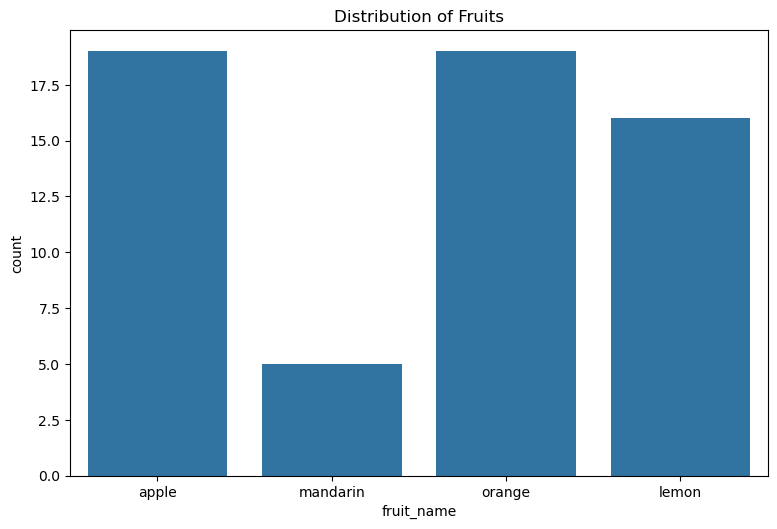

In [30]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='fruit_name')
plt.title('Distribution of Fruits')
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

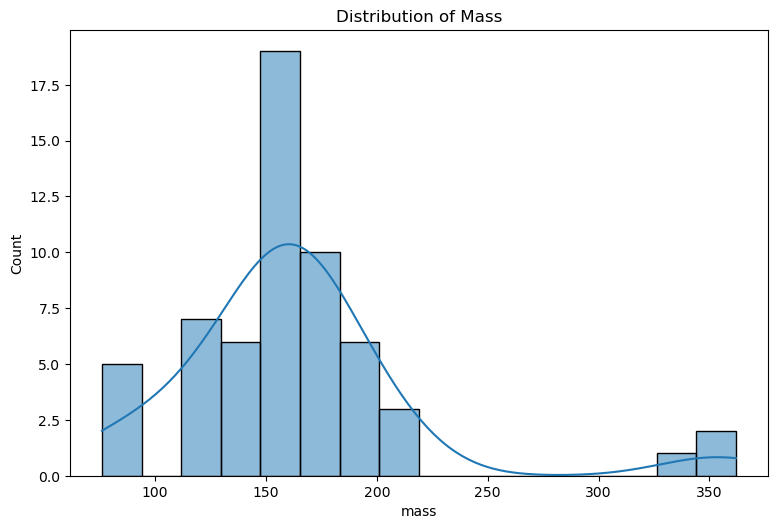

In [31]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='mass', kde=True)
plt.title('Distribution of Mass')
plt.tight_layout()
plt.show()

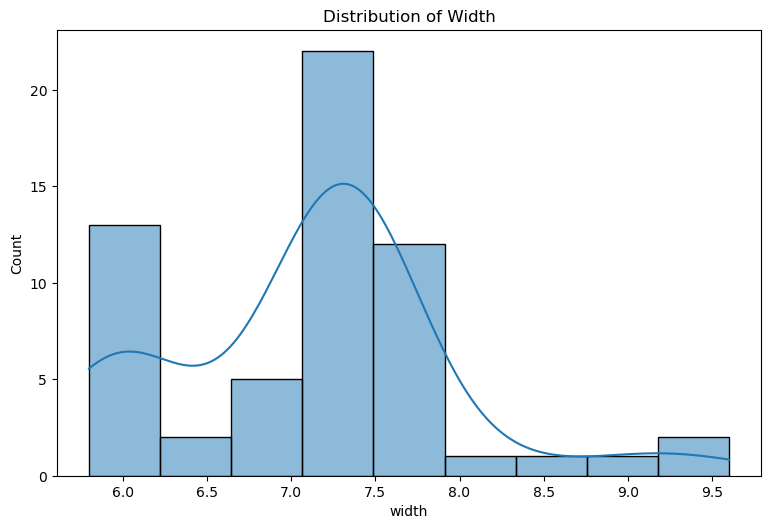

In [29]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='width', kde=True)
plt.title('Distribution of Width')
plt.tight_layout()
plt.show()

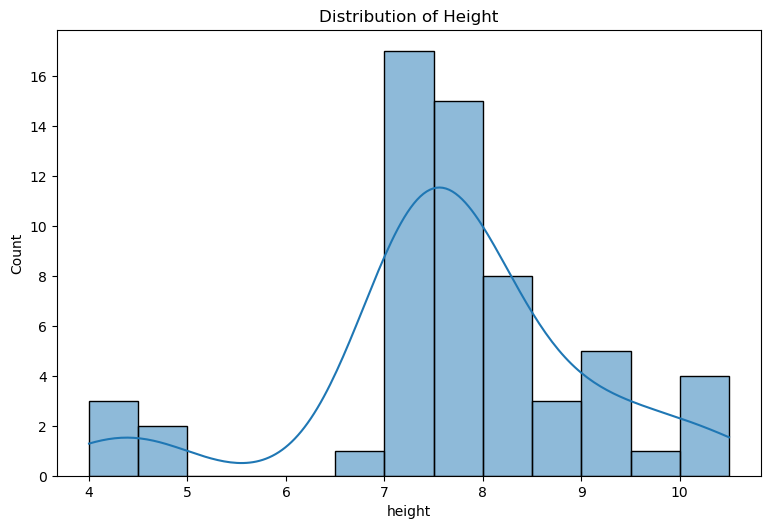

In [32]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='height', kde=True)
plt.title('Distribution of Height')
plt.tight_layout()
plt.show()

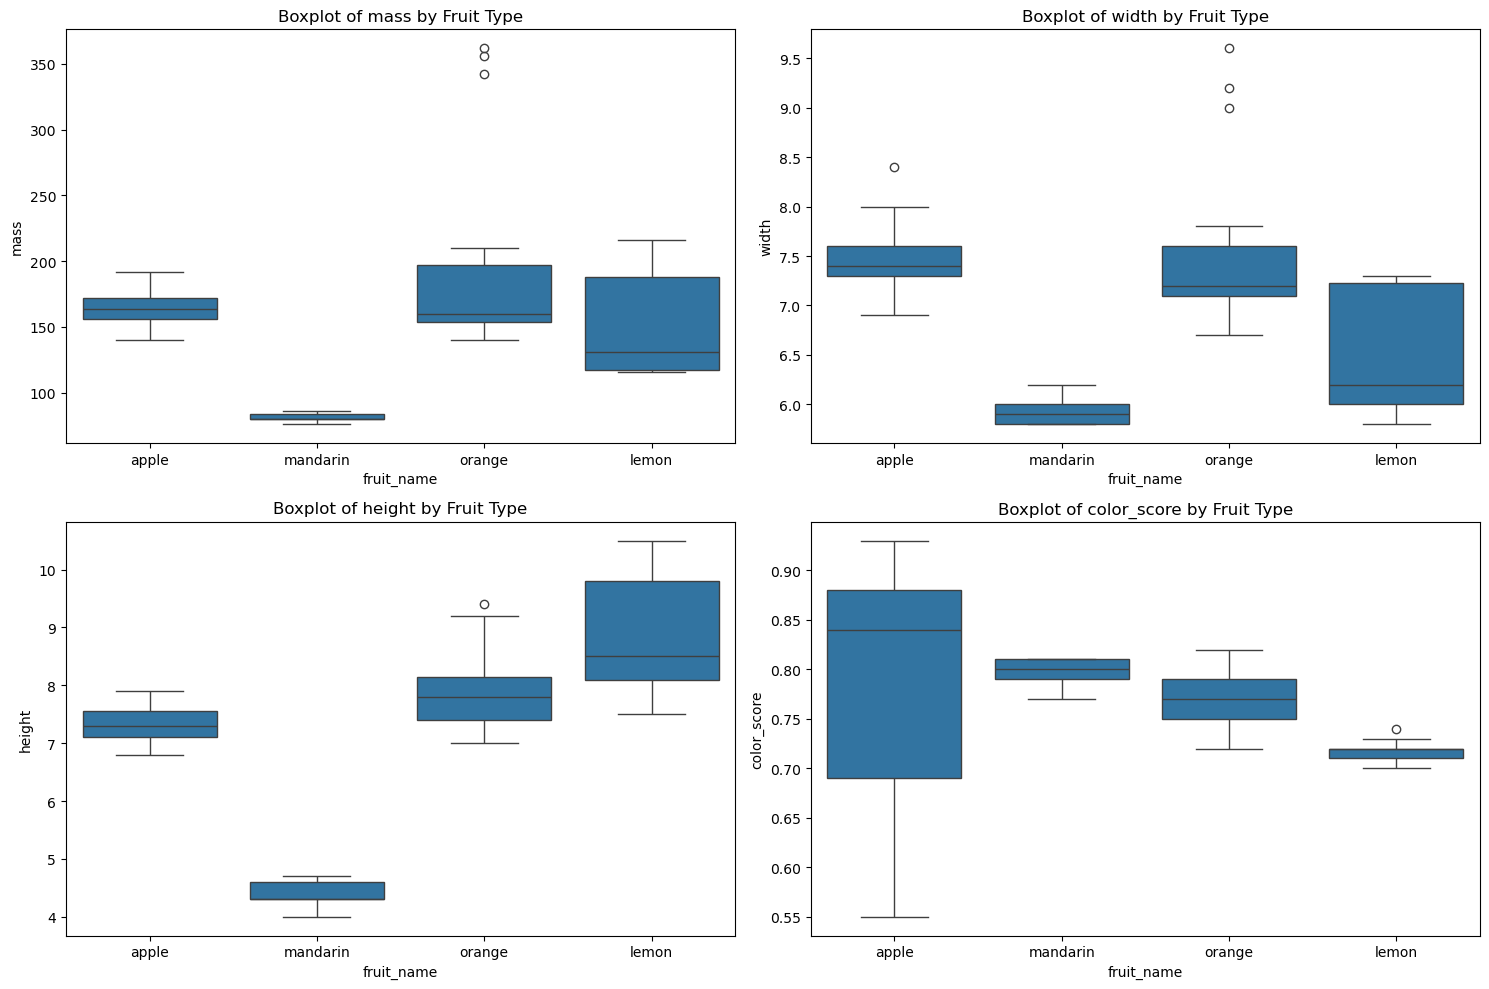

In [35]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['mass', 'width', 'height', 'color_score']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df, x='fruit_name', y=col)
    plt.title(f'Boxplot of {col} by Fruit Type')
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
df.isnull().sum()

fruit_label      0
fruit_name       0
fruit_subtype    0
mass             0
width            0
height           0
color_score      0
dtype: int64

In [71]:
label_encoder = LabelEncoder()
df['fruit_label'] = label_encoder.fit_transform(df['fruit_name'])

In [50]:
X = df[['mass', 'width', 'height', 'color_score']]
y = df['fruit_label']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

In [76]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n" + "="*80 + "\n")

Logistic Regression Accuracy: 0.9167
              precision    recall  f1-score   support

       apple       1.00      0.75      0.86         4
       lemon       1.00      1.00      1.00         3
    mandarin       1.00      1.00      1.00         1
      orange       0.80      1.00      0.89         4

    accuracy                           0.92        12
   macro avg       0.95      0.94      0.94        12
weighted avg       0.93      0.92      0.92        12

Confusion Matrix:
[[3 0 0 1]
 [0 3 0 0]
 [0 0 1 0]
 [0 0 0 4]]


Decision Tree Accuracy: 0.9167
              precision    recall  f1-score   support

       apple       0.80      1.00      0.89         4
       lemon       1.00      1.00      1.00         3
    mandarin       1.00      1.00      1.00         1
      orange       1.00      0.75      0.86         4

    accuracy                           0.92        12
   macro avg       0.95      0.94      0.94        12
weighted avg       0.93      0.92      0.92        1

In [77]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

C:\Users\hanum\AppData\Local\Temp\ipykernel_10176\2511107.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')


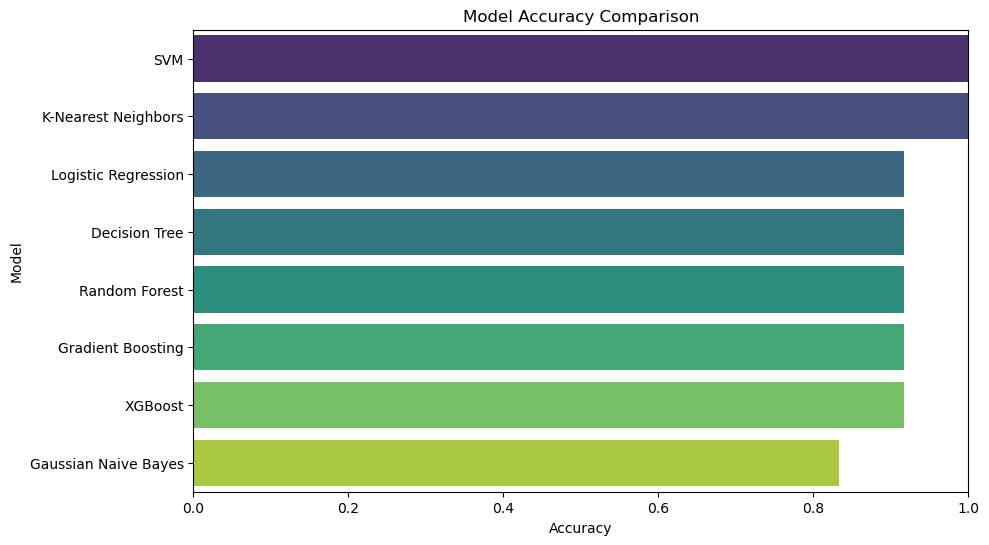

In [78]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 1)
plt.show()

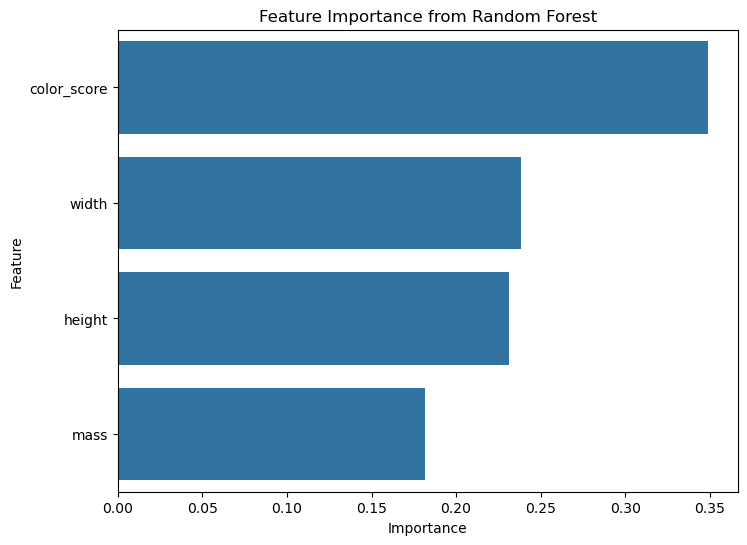

In [79]:
# Get feature importance from the best model (Random Forest in this case)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance from Random Forest')
plt.show()

In [80]:
import joblib
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [81]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

# Constants
DEFAULT_CLASSES = ['apple', 'mandarin', 'orange', 'lemon']  # Update with your actual class order
MODEL_FILES = ['best_model.pkl', 'scaler.pkl', 'label_encoder.pkl']

def load_model_artifacts():
    """Load and validate all model artifacts"""
    if not all(os.path.exists(f) for f in MODEL_FILES):
        raise FileNotFoundError("Model files not found. Please run train_models.py first.")
    
    artifacts = {
        'model': joblib.load('best_model.pkl'),
        'scaler': joblib.load('scaler.pkl'),
        'encoder': joblib.load('label_encoder.pkl')
    }
    
    # Validate LabelEncoder
    if not hasattr(artifacts['encoder'], 'classes_'):
        st.warning("LabelEncoder not properly fitted. Using default classes.")
        artifacts['encoder'] = LabelEncoder()
        artifacts['encoder'].classes_ = np.array(DEFAULT_CLASSES)
    
    return artifacts

def create_input_features():
    """Create input feature UI and collect values"""
    col1, col2 = st.columns(2)
    with col1:
        mass = st.slider('Mass (g)', min_value=50, max_value=300, value=150, step=1)
        width = st.slider('Width (cm)', min_value=5.0, max_value=15.0, value=8.0, 
                         step=0.1, format="%.1f")
    with col2:
        height = st.slider('Height (cm)', min_value=5.0, max_value=15.0, value=8.0, 
                         step=0.1, format="%.1f")
        color_score = st.slider('Color Score (0-1)', min_value=0.0, max_value=1.0, 
                              value=0.5, step=0.01, format="%.2f")
    return np.array([[mass, width, height, color_score]], dtype=np.float64)

def make_prediction(model, scaler, encoder, input_data):
    """Make prediction with proper error handling"""
    try:
        input_scaled = scaler.transform(input_data)
        prediction = model.predict(input_scaled)
        return encoder.inverse_transform(prediction.reshape(-1))[0]
    except Exception as e:
        st.error(f"Prediction failed: {str(e)}")
        return None

def main():
    # Page configuration
    st.set_page_config(page_title="Fruit Classifier", page_icon="🍎")
    st.title('🍎 Fruit Classification App')
    st.write("Predict the type of fruit based on its characteristics")
    
    try:
        # Load models
        artifacts = load_model_artifacts()
        
        # Get user input
        input_data = create_input_features()
        
        # Make prediction
        if st.button('Predict Fruit Type'):
            fruit_name = make_prediction(
                artifacts['model'],
                artifacts['scaler'],
                artifacts['encoder'],
                input_data
            )
            if fruit_name:
                st.success(f'The predicted fruit is: **{fruit_name}**')
                
    except Exception as e:
        st.error(f"Application error: {str(e)}")
        st.stop()

if __name__ == "__main__":
    main()

Overwriting app.py


In [82]:
!streamlit run app.py --server.port 8503

2025-04-12 10:44:39.942 Port 8503 is already in use
